In [ ]:

import torch
import GCN
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import dense_to_sparse, to_networkx
from torch_geometric.data import Data
from torch_geometric.explain import Explainer, GNNExplainer
import importlib
importlib.reload(GCN)

import plotly.graph_objects as go

import os
os.chdir('../')

In [ ]:


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


def heat_map(label1, label2, version, num_samples=10):
  

    # Load data
    data_x = np.load(f'../filtered_data/{label1}_{label2}_X_val.npy')
    data_adj = np.load(f'../filtered_data/{label1}_{label2}_adj_val.npy')
    data_y = np.load(f'../filtered_data/{label1}_{label2}_y_val.npy')

    coords = np.load(f'../filtered_data/{label1}_{label2}_coords.npy', allow_pickle=True)

    # Convert to tensors
    X_tensor = torch.tensor(data_x, dtype=torch.float).to(device)
    adj_tensor = torch.tensor(data_adj, dtype=torch.float).to(device)
    y_tensor = torch.tensor(data_y, dtype=torch.float).to(device)

    # Create dataset
    dataset = GCN.InterpreterDataset(X_tensor, adj_tensor, y_tensor)
    
    # Use a subset of samples (limit to available samples)
    num_samples = min(num_samples, len(dataset))

    # Load model
    model = GCN.GraphConv(20, 0.001).to(device)
    model.load_state_dict(torch.load(f'../models/model_{label1}_{label2}{version}.pt', map_location=device))
    model.eval()


    # Set up GNN Explainer
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=200),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(
            mode='regression',
            task_level='graph',  # since it's graph-level prediction
            return_type='raw',
        ),
    )

    print(f"Generating explanations for {num_samples} samples with different graph structures")

    # Generate explanations for multiple samples, each with their own graph structure
    # This captures variation across different topologies
    node_masks = []
    edge_importance_dict = {}  # Store edge importance by (node1, node2) tuple
    all_graphs = []
    
    for i in range(num_samples):
        data = dataset[i]
        data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
        
        # Each sample uses its own unique graph structure
        explanation = explainer(data.x, data.edge_index, edge_weight=data.edge_weight, batch=data.batch)
        node_masks.append(explanation.node_mask.cpu().numpy())
        
        # Store edge importances by edge tuple for aggregation
        edge_index_np = data.edge_index.cpu().numpy()
        edge_mask_np = explanation.edge_mask.cpu().numpy()
        
        for j in range(edge_index_np.shape[1]):
            edge = tuple(sorted([edge_index_np[0, j], edge_index_np[1, j]]))
            if edge not in edge_importance_dict:
                edge_importance_dict[edge] = []
            edge_importance_dict[edge].append(edge_mask_np[j])
        
        all_graphs.append(data)
    
    # Average the node masks across all samples (these are all the same size)
    avg_node_mask = np.mean(np.array(node_masks), axis=0)
    
    # Average edge importance for edges that appear across multiple graphs
    avg_edge_importance_dict = {edge: np.mean(importances) 
                                 for edge, importances in edge_importance_dict.items()}
    
    print(f"Averaged across {len(node_masks)} different graph structures")
    print(f"Found {len(avg_edge_importance_dict)} unique edges across all graphs")
    
    # Use the first sample's graph structure for visualization reference
    data = all_graphs[0]
    G = to_networkx(data, to_undirected=True)
    
    # Create edge mask for visualization using first graph's structure
    edge_index_np = data.edge_index.cpu().numpy()
    edge_mask = np.zeros(edge_index_np.shape[1])
    for j in range(edge_index_np.shape[1]):
        edge = tuple(sorted([edge_index_np[0, j], edge_index_np[1, j]]))
        edge_mask[j] = avg_edge_importance_dict.get(edge, 0.0)
    
    # Compute node importance as sum of absolute mask values per node
    node_importance = np.sum(np.abs(avg_node_mask), axis=1)

    # Normalize for coloring
    node_importance_norm = (node_importance - node_importance.min()) / (node_importance.max() - node_importance.min())

    # Use actual 3D coordinates from the first data point
    # coords[0] contains the 3D coordinates for the first sample
    coords_3d = coords[0]  # Shape: (num_nodes, 3)
    
    # Create position dictionary using the first two dimensions (x, y) for 2D visualization
    pos = {i: (coords_3d[i, 0], coords_3d[i, 1]) for i in range(len(coords_3d))}
    
    # Edge mask is already created above from avg_edge_importance_dict
    edges = list(G.edges())
    edge_colors = [edge_mask[i] for i in range(len(edges))]
    edge_widths = [3 + 3 * edge_mask[i] for i in range(len(edges))]  # Vary width based on importance

    # Combined Node and Edge Importance in One Graph - Enhanced for poster
    fig = plt.figure(figsize=(16, 12))
    fig.patch.set_facecolor('white')

    # Draw edges first with importance-based colors and widths
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, edge_cmap=plt.cm.Blues, 
                          width=edge_widths, alpha=0.85, edge_vmin=0)

    # Draw nodes with importance-based colors and enhanced styling
    nx.draw_networkx_nodes(G, pos, node_color=node_importance_norm, cmap=plt.cm.Reds, 
                          node_size=800, alpha=0.95, vmin=0, 
                          edgecolors='white', linewidths=3)

    # Draw labels with contrasting colors
    labels = {node: str(node) for node in G.nodes()}
    label_colors = {node: 'white' if node_importance_norm[node] > 0.5 else 'black' for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_color=label_colors, 
                           font_size=14, font_weight='bold')

    plt.title(f'Graph Explanation: {label1}_{label2}', fontsize=28, 
             fontweight='bold', pad=25, color='#2C3E50')

    # Add colorbars with enhanced styling
    # Node colorbar
    sm_node = plt.cm.ScalarMappable(cmap=plt.cm.Reds, 
                                   norm=plt.Normalize(vmin=0, vmax=node_importance.max()))
    sm_node.set_array([])
    cbar_node = plt.colorbar(sm_node, ax=plt.gca(), shrink=0.7, location='left', pad=0.05)
    cbar_node.set_label('Node Importance', fontsize=22, fontweight='bold', color='#2C3E50')
    cbar_node.ax.tick_params(labelsize=16, colors='#2C3E50', width=2, length=6)
    cbar_node.outline.set_edgecolor('#2C3E50')
    cbar_node.outline.set_linewidth(2)

    # Edge colorbar
    sm_edge = plt.cm.ScalarMappable(cmap=plt.cm.Blues, 
                                   norm=plt.Normalize(vmin=0, vmax=edge_mask.max()))
    sm_edge.set_array([])
    cbar_edge = plt.colorbar(sm_edge, ax=plt.gca(), shrink=0.7, location='right', pad=0.05)
    cbar_edge.set_label('Edge Importance', fontsize=22, fontweight='bold', color='#2C3E50')
    cbar_edge.ax.tick_params(labelsize=16, colors='#2C3E50', width=2, length=6)
    cbar_edge.outline.set_edgecolor('#2C3E50')
    cbar_edge.outline.set_linewidth(2)

    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'../pictures/{label1}_{label2}/graph_map_{version}.png', dpi=300, 
               bbox_inches='tight', facecolor='white')
    plt.show()

    # Heatmap for Node Feature Importance
    # Read feature labels from properties.txt
    with open('../properties.txt', 'r') as f:
        lines = f.readlines()
        feature_labels = [line.split(',')[0] for line in lines[:20]]  # First 20 properties

    feature_labels = feature_labels[1:]
    feature_labels = np.append(feature_labels, 'ChargeState')

    # Average feature importance across all samples and all nodes
    avg_node_feat_mask = np.mean(avg_node_mask, axis=0)

    # Enhanced feature importance bar plot
    fig, ax = plt.subplots(figsize=(16, 9))
    fig.patch.set_facecolor('white')
    
    # Create color gradient
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(avg_node_feat_mask)))
    bars = ax.bar(range(len(avg_node_feat_mask)), avg_node_feat_mask, color=colors, 
                  alpha=0.85, edgecolor='white', linewidth=2, width=0.8)
    
    ax.set_ylabel('Feature Importance', fontsize=24, fontweight='bold', 
                  color='#2C3E50', labelpad=10)
    ax.set_title(f'Feature Importance: {label1}_{label2}', 
                fontsize=28, fontweight='bold', pad=25, color='#2C3E50')
    ax.set_xticks(range(len(avg_node_feat_mask)))
    ax.set_xticklabels(feature_labels, rotation=45, ha='right', fontsize=18, 
                       fontweight='bold', color='#2C3E50')
    
    # Enhanced grid and styling
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.2, zorder=1)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=18, colors='#2C3E50', width=2, length=6)
    
    # Spine styling
    for spine in ax.spines.values():
        spine.set_edgecolor('#2C3E50')
        spine.set_linewidth(2)
    
    ax.set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    plt.savefig(f'../pictures/{label1}_{label2}/node_map_{version}.png', dpi=300, 
               bbox_inches='tight', facecolor='white')
    plt.show()





In [4]:
from util import getProps, getInversePeriodicTable, init_properties

TYPE = "First"
TYPE2 = "hse"

inputFeatureVectorList = np.load(f"../filtered_data/input{TYPE}FeatureVector.npy").astype(np.double)
chargeStateList = np.load(f"../filtered_data/defect{TYPE}ChargeState.npy", allow_pickle=True)

inputFeatureVectorList_NonOHE = np.argmax(inputFeatureVectorList, axis=2).tolist()

for n in range(len(inputFeatureVectorList_NonOHE)):
    for node in range(len(inputFeatureVectorList_NonOHE[n])):
        # Convert atomic number to element symbol, then get properties
        element_symbol = getInversePeriodicTable(inputFeatureVectorList_NonOHE[n][node], "../properties.txt")
        inputFeatureVectorList_NonOHE[n][node] = list(getProps(element_symbol, "../properties.txt"))
        inputFeatureVectorList_NonOHE[n][node].append(float(chargeStateList[n]))

outputLabelList = np.load(f"../filtered_data/output{TYPE}FeatureVector.npy", allow_pickle=True)
adjMatrix = np.load(f"../filtered_data/{TYPE2}{TYPE}AdjacencyMatrix.npy", allow_pickle=True)

# change for pbe
coordinates = np.load(f'../filtered_data/hse{TYPE}FilteredCordsList.npy', allow_pickle=True)
# Keep distances for edges below threshold, set others to 0 (no edge)
DISTANCE_THRESHOLD = .25
adjMatrix = np.where(adjMatrix < DISTANCE_THRESHOLD, (DISTANCE_THRESHOLD - adjMatrix)/DISTANCE_THRESHOLD, 0)


In [ ]:
from scipy import stats

#adjacencyList = np.load("filtered_data/hseAdjacencyList.npy", allow_pickle=True)



def heat_map_interactive_3d(label1, label2, version, title, save=False, show=True, num_samples=10):

    
    # Use the data already loaded in the previous cell
    data_x = np.array(inputFeatureVectorList_NonOHE)
    data_adj = adjMatrix
    coords = coordinates

    data_x = data_x[:, :15, :]
    data_adj = data_adj[:, :15, :15]
    coords = coords[:, :15, :]


    for cord in coords:
        offset = cord[0]
        cord -= offset  # Translate so first atom is at origin


    coords_aggregated = coords[0] #stats.trim_mean(coords, proportiontocut=0.1, axis=0)



    # Convert to tensors
    X_tensor = torch.tensor(data_x, dtype=torch.float).to(device)
    adj_tensor = torch.tensor(data_adj, dtype=torch.float).to(device)
    # Create dummy y data (not actually used by the explainer, only needed for dataset creation)
    y_tensor = torch.zeros(len(X_tensor), dtype=torch.float).to(device)

    # Create dataset
    dataset = GCN.InterpreterDataset(X_tensor, adj_tensor, y_tensor)
    num_samples = min(num_samples, len(dataset))

    # Load model
    model = GCN.GraphConv(20, 0.001).to(device)
    model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_location=device, weights_only=True))
    model.eval()

    # Set up GNN Explainer
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=200),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(
            mode='regression',
            task_level='graph',
            return_type='raw',
        ),
    )

    print(f"Generating explanations for {num_samples} samples...")

    # Generate explanations
    node_masks = []
    edge_importance_dict = {}
    all_graphs = []
    
    for i in range(num_samples):
        data = dataset[i]
        data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
        
        explanation = explainer(data.x, data.edge_index, edge_weight=data.edge_weight, batch=data.batch)
        node_masks.append(explanation.node_mask.cpu().numpy())
        
        edge_index_np = data.edge_index.cpu().numpy()
        edge_mask_np = explanation.edge_mask.cpu().numpy()
        
        for j in range(edge_index_np.shape[1]):
            edge = tuple(sorted([edge_index_np[0, j], edge_index_np[1, j]]))
            if edge not in edge_importance_dict:
                edge_importance_dict[edge] = []
            edge_importance_dict[edge].append(edge_mask_np[j])
        
        all_graphs.append(data)
    
    # Average masks
    avg_node_mask = np.mean(np.array(node_masks), axis=0)
    avg_edge_importance_dict = {edge: np.mean(importances) 
                                 for edge, importances in edge_importance_dict.items()}
    

    
    # Compute node importance
    node_importance = np.sum(np.abs(avg_node_mask), axis=1)
    node_importance_norm = (node_importance - node_importance.min()) / (node_importance.max() - node_importance.min())
    
    # Get 3D coordinates
    coords_3d = coords_aggregated  # Shape: (num_nodes, 3)
    
    # Create edge traces
    edge_traces = []
    edge_index_np = data.edge_index.cpu().numpy()
    edge_importances = []  # Collect all edge importances for colorbar
    
    for j in range(edge_index_np.shape[1]):
        node1, node2 = edge_index_np[0, j], edge_index_np[1, j]
        edge = tuple(sorted([node1, node2]))
        edge_importance = avg_edge_importance_dict.get(edge, 0.0)
        edge_importances.append(edge_importance)
        
        # Edge coordinates
        x_coords = [coords_3d[node1, 0], coords_3d[node2, 0], None]
        y_coords = [coords_3d[node1, 1], coords_3d[node2, 1], None]
        z_coords = [coords_3d[node1, 2], coords_3d[node2, 2], None]
        
        # Color based on importance (blue scale)
        edge_color = f'rgba(0, 0, {int(255 * edge_importance)}, {0.6 + 0.4 * edge_importance})'
        
        edge_trace = go.Scatter3d(
            x=x_coords, y=y_coords, z=z_coords,
            mode='lines',
            line=dict(color=edge_color, width=2 + 8 * edge_importance),
            hovertemplate=f'<b>Edge {node1}-{node2}</b><br>Importance: {edge_importance:.3f}<extra></extra>',
            showlegend=False
        )
        edge_traces.append(edge_trace)
    
    # Create invisible scatter for edge importance colorbar
    edge_colorbar_trace = go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode='markers',
        marker=dict(
            size=0.1,
            color=[0, max(edge_importances) if edge_importances else 1],
            colorscale='Blues',
            showscale=True,
            colorbar=dict(
                title="Edge<br>Importance",
                thickness=15,
                len=0.5,
                x=-0.15,
                xanchor='left'
            )
        ),
        showlegend=False,
        hoverinfo='skip'
    )
    
    # Create node trace
    node_x = coords_3d[:, 0]
    node_y = coords_3d[:, 1]
    node_z = coords_3d[:, 2]
    
    node_trace = go.Scatter3d(
        x=node_x, y=node_y, z=node_z,
        mode='markers+text',
        marker=dict(
            size=10,
            color=node_importance_norm,
            colorscale='Reds',
            showscale=True,
            colorbar=dict(
                title="Node<br>Importance",
                thickness=15,
                len=0.5,
                x=1.05
            ),
            line=dict(color='white', width=2)
        ),
        text=[str(i) for i in range(len(node_x))],
        textposition="top center",
        textfont=dict(size=10, color='black'),
        hovertemplate='<b>Node %{text}</b><br>' +
                      'Position: (%{x:.2f}, %{y:.2f}, %{z:.2f})<br>' +
                      'Importance: %{marker.color:.3f}<br>' +
                      '<extra></extra>',
        name='Nodes'
    )
    
    # Create figure
    fig = go.Figure(data=edge_traces + [edge_colorbar_trace, node_trace])

    # Update layout
    fig.update_layout(
        title=dict(
            text=f'<b>{title}</b>',
            font=dict(size=24, color='#2C3E50', family='Arial'),
            x=0.5,
            xanchor='center',
            y=0.98,
            yanchor='top'
        ),
        scene=dict(
            xaxis=dict(title='X', backgroundcolor="rgb(230, 230,230)", gridcolor="white"),
            yaxis=dict(title='Y', backgroundcolor="rgb(230, 230,230)", gridcolor="white"),
            zaxis=dict(title='Z', backgroundcolor="rgb(230, 230,230)", gridcolor="white"),
            aspectmode='data',
            camera=dict(
                eye=dict(x=1.1, y=.9, z=1.1),
                center=dict(x=0, y=0, z=0),
                up=dict(x=0, y=0, z=1)
            )
        ),
        width=1000,
        height=800,
        showlegend=False,
        hovermode='closest',
        margin=dict(l=0, r=0, b=0, t=40),
        paper_bgcolor='white',
        plot_bgcolor='white'
    )
    
    if show:
        fig.show()

    
    # Save as HTML (interactive)
    if save:
        fig.write_html(f'./pictures2/{label1}_{label2}/interactive_3d_graph_{version}.html')
        print(f"Saved interactive plot to ./pictures2/{label1}_{label2}/interactive_3d_graph_{version}.html")

        
    
        # Save as SVG (static image) - requires kaleido package
        try:
            fig.write_image(f'./pictures2/{label1}_{label2}/interactive_3d_graph_{version}.png')
            fig.write_image(f'./pictures2/{label1}_{label2}/interactive_3d_graph_{version}.svg')
            print(f"Saved static SVG to ./pictures2/{label1}_{label2}/interactive_3d_graph_{version}.svg")
        except Exception as e:
            print(f"Could not save SVG (install kaleido package): {e}")


In [39]:

LABELS = [
    ('hse-ex1', 'defect_hse_excited_deltaQ', '4.0'),
    ("hse-ex1", "defect_zero_phonon_line", '4.0'), 
    ('hse-gs', 'defect_total_energy', '4.0'), 
    ('hse-gs', 'defect_fermi_energy', '4.0'),
    ('pbe-gs', 'defect_cbm-vbm_energy', '4.0'),
    ('pbe-gs', 'defect_initial_pbe_deltaQ', '4.0'),
    ('pbe-gs', 'defect_initial_pbe_deltaR', '4.0'),
    ('pbe-gs', 'defect_electron_affinity', '4.0'),
    ('pbe-gs', 'defect_ionization_energy', '4.0')
]

NAMES = [
    "Excited State Delta Q",
    "Zero Phonon Line",
    "Defect Energy",
    "Fermi Energy",
    "CBM-VBM Energy",
    "Initial PBE Delta Q",
    "Initial PBE Delta R",
    "Electron Affinity",
    "Ionization Energy"
]


for (label1, label2, version), title in zip(LABELS, NAMES):
    heat_map_interactive_3d(label1, label2, version, title, save=True, show=False, num_samples=50)

Generating explanations for 36 samples...
Saved interactive plot to ./pictures2/hse-ex1_defect_hse_excited_deltaQ/interactive_3d_graph_4.0.html
Saved interactive plot to ./pictures2/hse-ex1_defect_hse_excited_deltaQ/interactive_3d_graph_4.0.html
Saved static SVG to ./pictures2/hse-ex1_defect_hse_excited_deltaQ/interactive_3d_graph_4.0.svg
Generating explanations for 36 samples...
Saved static SVG to ./pictures2/hse-ex1_defect_hse_excited_deltaQ/interactive_3d_graph_4.0.svg
Generating explanations for 36 samples...
Saved interactive plot to ./pictures2/hse-ex1_defect_zero_phonon_line/interactive_3d_graph_4.0.html
Saved interactive plot to ./pictures2/hse-ex1_defect_zero_phonon_line/interactive_3d_graph_4.0.html
Saved static SVG to ./pictures2/hse-ex1_defect_zero_phonon_line/interactive_3d_graph_4.0.svg
Generating explanations for 36 samples...
Saved static SVG to ./pictures2/hse-ex1_defect_zero_phonon_line/interactive_3d_graph_4.0.svg
Generating explanations for 36 samples...
Saved inte

/tmp/ipykernel_9876/3145460529.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_loc

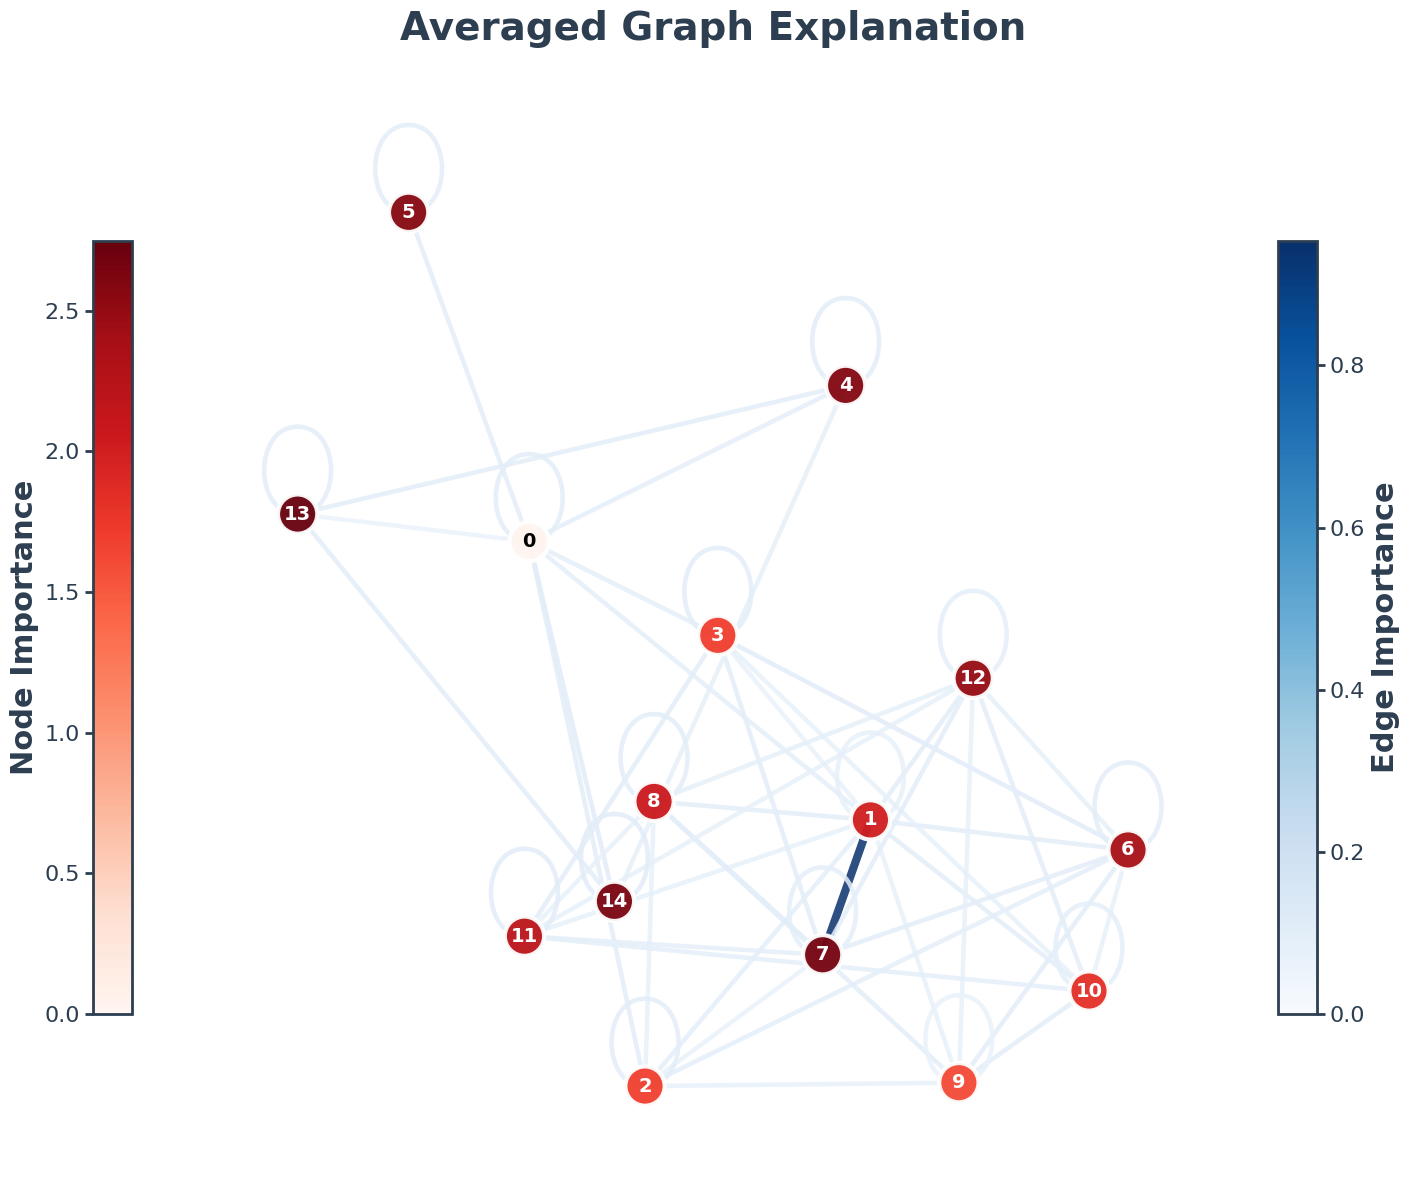

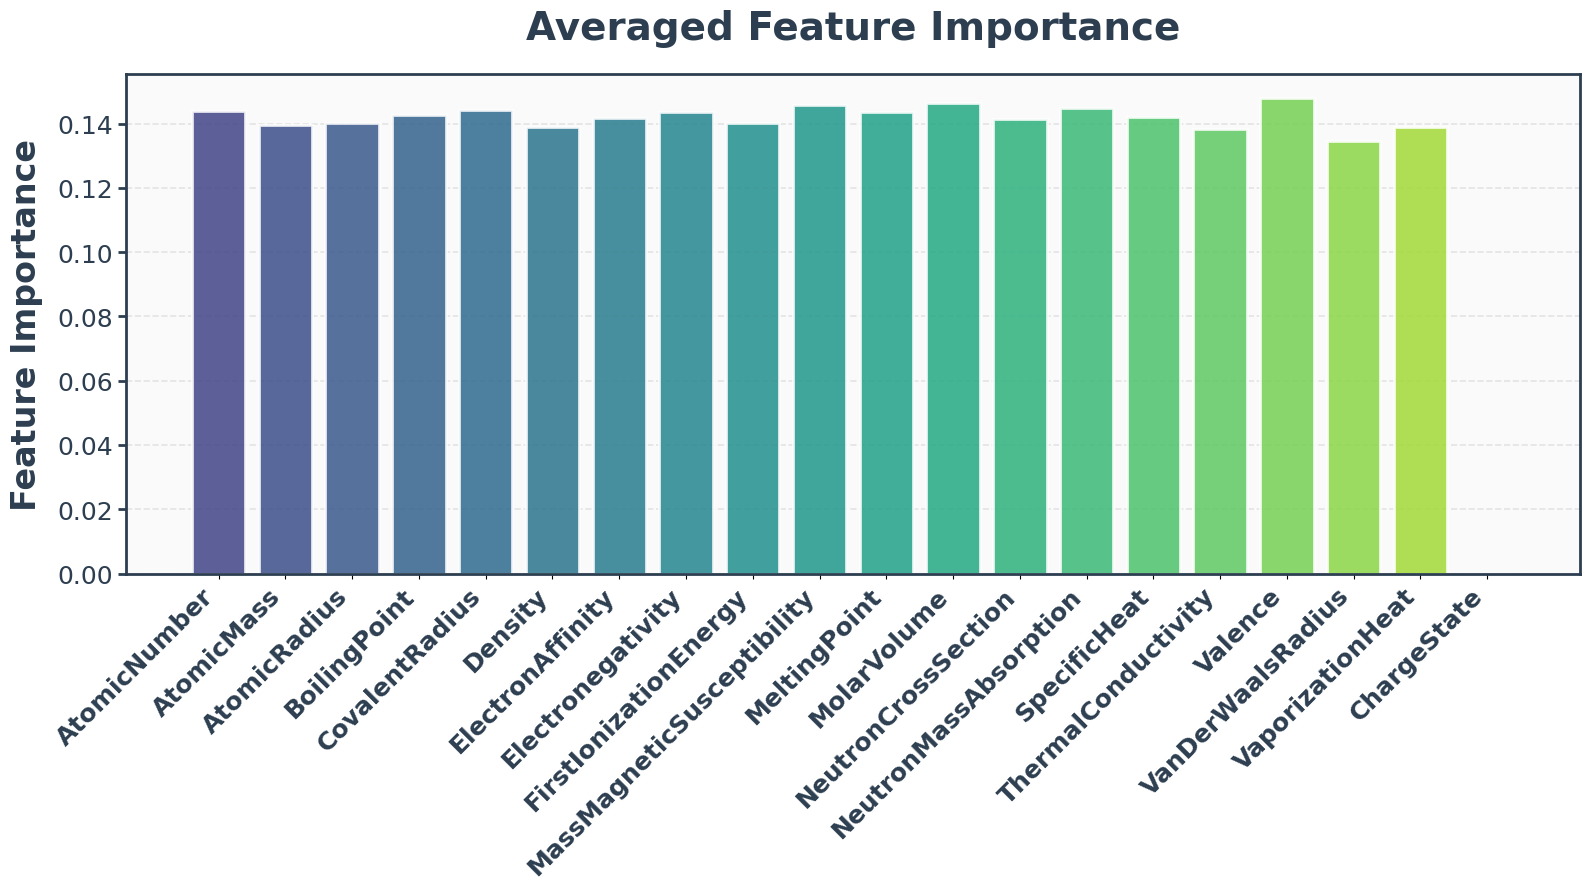

In [12]:
def averaged_graph(data_list, save=False, show=True):

    # Use data from the first model
    first_label1, first_label2, first_version = data_list[0]
    data_x = np.load(f'filtered_data/{first_label1}_{first_label2}_X_val.npy')
    data_adj = np.load(f'filtered_data/{first_label1}_{first_label2}_adj_val.npy')
    data_y = np.load(f'filtered_data/{first_label1}_{first_label2}_y_val.npy')

    # Take first sample
    X = torch.tensor(data_x[0], dtype=torch.float).to(device)
    adj = torch.tensor(data_adj[0], dtype=torch.float).to(device)
    y = torch.tensor(data_y[0], dtype=torch.float).to(device)

    # Convert to PyG data
    edge_index, edge_weight = dense_to_sparse(adj[:GCN.GRAPH_SIZE, :GCN.GRAPH_SIZE])
    data = Data(x=X[:GCN.GRAPH_SIZE], edge_index=edge_index, edge_weight=edge_weight, y=y)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)

    node_masks = []
    edge_masks = []
    node_feat_masks = []

    for (label1, label2, version) in data_list:
        # Load model
        model = GCN.GraphConv(20, 0.001).to(device)
        model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_location=device))
        model.eval()

        # Set up GNN Explainer
        explainer = Explainer(
            model=model,
            algorithm=GNNExplainer(epochs=200),
            explanation_type='model',
            node_mask_type='attributes',
            edge_mask_type='object',
            model_config=dict(
                mode='regression',
                task_level='graph',  # since it's graph-level prediction
                return_type='raw',
            ),
        )

        # Generate explanation for the graph
        explanation = explainer(data.x, data.edge_index, edge_weight=data.edge_weight, batch=data.batch)

        node_mask = explanation.node_mask.cpu().numpy()
        edge_mask = explanation.edge_mask.cpu().numpy()
        node_feat_mask = np.mean(explanation.node_mask.cpu().numpy(), axis=0)

        node_masks.append(node_mask)
        edge_masks.append(edge_mask)
        node_feat_masks.append(node_feat_mask)
    
    # Average masks
    avg_node_map = np.mean(np.array(node_masks), axis=0)
    avg_edge_map = np.mean(np.array(edge_masks), axis=0)
    avg_node_feat_map = np.mean(np.array(node_feat_masks), axis=0)

    G = to_networkx(data, to_undirected=True)

    # Compute node importance as sum of absolute mask values per node
    node_importance = np.sum(np.abs(avg_node_map), axis=1)

    # Normalize for coloring
    node_importance_norm = (node_importance - node_importance.min()) / (node_importance.max() - node_importance.min())

    pos = nx.spring_layout(G, seed=42, k=1.6)  # Adjust k for spacing
    # Visualize edge importance
    edge_mask = avg_edge_map

    edges = list(G.edges())
    edge_colors = [edge_mask[i] for i in range(len(edges))]
    edge_widths = [3 + 3 * edge_mask[i] for i in range(len(edges))]  # Vary width based on importance

    # Combined Node and Edge Importance in One Graph - Enhanced for poster
    fig = plt.figure(figsize=(16, 12))
    fig.patch.set_facecolor('white')

    # Draw edges first with importance-based colors and widths
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, edge_cmap=plt.cm.Blues, 
                          width=edge_widths, alpha=0.85, edge_vmin=0)

    # Draw nodes with importance-based colors and enhanced styling
    nx.draw_networkx_nodes(G, pos, node_color=node_importance_norm, cmap=plt.cm.Reds, 
                          node_size=800, alpha=0.95, vmin=0,
                          edgecolors='white', linewidths=3)

    # Draw labels with contrasting colors
    labels = {node: str(node) for node in G.nodes()}
    label_colors = {node: 'white' if node_importance_norm[node] > 0.5 else 'black' for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_color=label_colors, 
                           font_size=14, font_weight='bold')

    plt.title('Averaged Graph Explanation', fontsize=28, 
             fontweight='bold', pad=25, color='#2C3E50')

    # Add colorbars with enhanced styling
    # Node colorbar
    sm_node = plt.cm.ScalarMappable(cmap=plt.cm.Reds, 
                                   norm=plt.Normalize(vmin=0, vmax=node_importance.max()))
    sm_node.set_array([])
    cbar_node = plt.colorbar(sm_node, ax=plt.gca(), shrink=0.7, location='left', pad=0.05)
    cbar_node.set_label('Node Importance', fontsize=22, fontweight='bold', color='#2C3E50')
    cbar_node.ax.tick_params(labelsize=16, colors='#2C3E50', width=2, length=6)
    cbar_node.outline.set_edgecolor('#2C3E50')
    cbar_node.outline.set_linewidth(2)

    # Edge colorbar
    sm_edge = plt.cm.ScalarMappable(cmap=plt.cm.Blues, 
                                   norm=plt.Normalize(vmin=0, vmax=edge_mask.max()))
    sm_edge.set_array([])
    cbar_edge = plt.colorbar(sm_edge, ax=plt.gca(), shrink=0.7, location='right', pad=0.05)
    cbar_edge.set_label('Edge Importance', fontsize=22, fontweight='bold', color='#2C3E50')
    cbar_edge.ax.tick_params(labelsize=16, colors='#2C3E50', width=2, length=6)
    cbar_edge.outline.set_edgecolor('#2C3E50')
    cbar_edge.outline.set_linewidth(2)

    plt.axis('off')
    plt.tight_layout()
    if save:
        plt.savefig(f'./pictures/poster/averaged_graph_map.png', dpi=300, 
                   bbox_inches='tight', facecolor='white')
    if show:
        plt.show()
    else:
        plt.close()

    # Heatmap for Averaged Node 0 Feature Vector
    # Read feature labels from properties.txt
    with open('properties.txt', 'r') as f:
        lines = f.readlines()
        feature_labels = [line.split(',')[0] for line in lines[:20]]  # First 20 properties

    feature_labels = feature_labels[1:]
    feature_labels = np.append(feature_labels, 'ChargeState')

    # Enhanced averaged feature importance bar plot
    fig, ax = plt.subplots(figsize=(16, 9))
    fig.patch.set_facecolor('white')
    
    # Create color gradient
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(avg_node_feat_map)))
    bars = ax.bar(range(len(avg_node_feat_map)), avg_node_feat_map, color=colors, 
                  alpha=0.85, edgecolor='white', linewidth=2, width=0.8)
    
    ax.set_ylabel('Feature Importance', fontsize=24, fontweight='bold', 
                  color='#2C3E50', labelpad=10)
    ax.set_title('Averaged Feature Importance', fontsize=28, 
                fontweight='bold', pad=25, color='#2C3E50')
    ax.set_xticks(range(len(avg_node_feat_map)))
    ax.set_xticklabels(feature_labels, rotation=45, ha='right', fontsize=18, 
                       fontweight='bold', color='#2C3E50')
    
    # Enhanced grid and styling
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.2, zorder=1)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=18, colors='#2C3E50', width=2, length=6)
    
    # Spine styling
    for spine in ax.spines.values():
        spine.set_edgecolor('#2C3E50')
        spine.set_linewidth(2)
    
    ax.set_facecolor('#FAFAFA')
    
    plt.tight_layout()

    if save:
        plt.savefig(f'./pictures/poster/averaged_node_map.png', dpi=300, 
               bbox_inches='tight', facecolor='white')
    if show:
        plt.show()
    else:
        plt.close()


labels = [
            # ('pbe-gs', 'defect_ionization_energy', '4.0'), 
            # ('pbe-gs', 'defect_initial_pbe_deltaQ', '4.0'),
            # ('pbe-gs', 'defect_initial_pbe_deltaR', '4.0'), 
            # ('pbe-gs', 'defect_electron_affinity', '4.0'),
            # ('pbe-gs', 'defect_cbm-vbm_energy', '4.0'),
            # ('hse-gs', 'defect_total_energy', '4.0'),
            # ('hse-gs', 'defect_lvl_tdm', '4.0'),
            # ('hse-gs', 'defect_fermi_energy', '4.0'),
            # ('hse-gs', 'defect_vbm_energy', '4.0'),
            ('hse-ex1', 'defect_zero_phonon_line', '4.0'),
            # ('hse-ex1', 'defect_hse_excited_deltaQ', '4.0')
            ]


averaged_graph(labels, save=False, show=True)



In [ ]:
def feature_importance_and_power_plot(labels_list, num_samples=10):

    # Read feature labels from properties.txt
    with open('../properties.txt', 'r') as f:
        lines = f.readlines()
        feature_labels = [line.split(',')[0] for line in lines[:20]]
    
    feature_labels = feature_labels[1:]
    feature_labels = np.append(feature_labels, 'ChargeState')
    
    results = []
    
    for label1, label2, version in labels_list:
        
        # === Feature Importance Analysis ===
        # Load data
        data_x = np.load(f'../filtered_data/{label1}_{label2}_X_val.npy')
        data_adj = np.load(f'../filtered_data/{label1}_{label2}_adj_val.npy')
        data_y = np.load(f'../filtered_data/{label1}_{label2}_y_val.npy')
        
        # Convert to tensors
        X_tensor = torch.tensor(data_x, dtype=torch.float).to(device)
        adj_tensor = torch.tensor(data_adj, dtype=torch.float).to(device)
        y_tensor = torch.tensor(data_y, dtype=torch.float).to(device)
        
        # Create dataset
        dataset = GCN.InterpreterDataset(X_tensor, adj_tensor, y_tensor)
        num_samples_actual = min(num_samples, len(dataset))
        
        # Load model
        model = GCN.GraphConv(20, 0.001).to(device)
        model.load_state_dict(torch.load(f'../models/model_{label1}_{label2}{version}.pt', map_location=device))
        model.eval()
        
        # Set up GNN Explainer
        explainer = Explainer(
            model=model,
            algorithm=GNNExplainer(epochs=200),
            explanation_type='model',
            node_mask_type='attributes',
            edge_mask_type='object',
            model_config=dict(
                mode='regression',
                task_level='graph',
                return_type='raw',
            ),
        )
        
        # Generate explanations for multiple samples
        node_masks = []
        for i in range(num_samples_actual):
            data = dataset[i]
            data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
            explanation = explainer(data.x, data.edge_index, edge_weight=data.edge_weight, batch=data.batch)
            node_masks.append(explanation.node_mask.cpu().numpy())
        
        # Average node masks and compute feature importance
        avg_node_mask = np.mean(np.array(node_masks), axis=0)
        avg_node_feat_mask = np.mean(avg_node_mask, axis=0)
        
        # Get top 2 features
        top_2_indices = np.argsort(avg_node_feat_mask)[-2:][::-1]
        top_2_features = [feature_labels[i] for i in top_2_indices]
        top_2_values = [avg_node_feat_mask[i] for i in top_2_indices]
        
        # === Predictive Power Calculation ===
        # Prepare validation dataset for prediction
        val_graphs = []
        for i in range(len(X_tensor)):
            edge_index, _ = dense_to_sparse(adj_tensor[i, :GCN.GRAPH_SIZE, :GCN.GRAPH_SIZE])
            data = Data(x=X_tensor[i, :GCN.GRAPH_SIZE], edge_index=edge_index)
            val_graphs.append(data)
        
        # Predict on validation set
        preds = []
        with torch.no_grad():
            for data in val_graphs:
                x = data.x
                edge_index = data.edge_index
                batch = torch.zeros(x.size(0), dtype=torch.long, device=device)
                pred = model(x, data.edge_index, data.edge_weight, batch)
                preds.append(pred.cpu().numpy().flatten()[0])
        
        preds = np.array(preds)
        y_true = y_tensor.cpu().numpy().flatten()
        residuals = preds - y_true
        
        # Calculate predictive power
        amount = len(y_true)
        random_guess_error = 0
        for i in range(amount):
            random_guess = np.random.uniform(0, 1)
            random_guess_error += (random_guess - y_true[i])**2
        random_guess_error /= amount
        
        mean_guess = np.mean(y_true)
        mean_guess_error = np.mean((mean_guess - y_true) ** 2)
        
        prediction_power_mean = random_guess_error / mean_guess_error
        prediction_power_val = random_guess_error / np.mean(residuals**2)
        
        # Store results
        results.append({
            'label': f"{label1}_{label2}",
            'top_feature_1': top_2_features[0],
            'top_value_1': top_2_values[0],
            'top_feature_2': top_2_features[1],
            'top_value_2': top_2_values[1],
            'predictive_power': prediction_power_val,
            'mean_power': prediction_power_mean
        })
    
    # === Create Visualization ===
    # Horizontal bar graph: features on left, label in middle, predictive power on right
    fig, ax = plt.subplots(figsize=(16, 1.5 * len(results)+.5))
    
    y_positions = range(len(results))
    bar_height = 0.3
    
    # Prepare data for all models
    labels_text = []
    feature1_values = []
    feature2_values = []
    power_values = []
    mean_power_values = []
    feature1_names = []
    feature2_names = []
    
    for result in results:
        labels_text.append(result['label'].replace('_', ' '))
        feature1_values.append(result['top_value_1'])
        feature2_values.append(result['top_value_2'])
        power_values.append(result['predictive_power'])
        mean_power_values.append(result['mean_power'])
        feature1_names.append(result['top_feature_1'])
        feature2_names.append(result['top_feature_2'])
    
    # Colors
    feature1_color = '#E74C3C'  # Red
    feature2_color = '#E67E22'  # Orange
    power_color = '#27AE60'     # Green (GNN)
    mean_color = '#3498DB'      # Blue (Mean)
    random_color = '#95A5A6'    # Gray (Random)    
    # Normalize values so left and right take equal space
    # Left side: normalize features to -1.0 scale
    max_feature = max(feature1_values + feature2_values)
    feature1_normalized = [-v / max_feature for v in feature1_values]
    feature2_normalized = [-v / max_feature for v in feature2_values]
    
    # Right side: normalize all power values to 1.0 scale
    max_power = max(power_values + mean_power_values + [1.0])  # Include random guess baseline
    power_normalized = [v / max_power for v in power_values]
    mean_power_normalized = [v / max_power for v in mean_power_values]
    random_power_normalized = [1.0 / max_power] * len(results)  # Random guess = 1.0
    
    # Create horizontal bars with normalized values
    # Features on the LEFT (negative x values, normalized)
    # Use same bar positions as right side for consistent height
    ax.barh([y - bar_height/2 for y in y_positions], 
                      feature1_normalized, height=bar_height,
                      color=feature1_color, alpha=0.85, edgecolor='white', linewidth=2,
                      label='Top Feature', zorder=3)
    ax.barh([y + bar_height/2 for y in y_positions], 
                      feature2_normalized, height=bar_height,
                      color=feature2_color, alpha=0.85, edgecolor='white', linewidth=2,
                      label='2nd Feature', zorder=3)
    
    # Predictive power on the RIGHT (positive x values, normalized)
    # Two bars: Mean and GNN (removed Random)
    ax.barh([y + bar_height/2 for y in y_positions], 
                       mean_power_normalized, height=bar_height,
                       color=mean_color, alpha=0.85, edgecolor='white', linewidth=2,
                       label='Mean Guess', zorder=3)
    ax.barh([y - bar_height/2 for y in y_positions], 
                      power_normalized, height=bar_height,
                      color=power_color, alpha=0.85, edgecolor='white', linewidth=2,
                      label='GNN Prediction', zorder=3)

    ax.barh([y + bar_height*1.6 for y in y_positions], 4, height=bar_height, color='none', zorder=5)  # Invisible bar for spacing

    # Add value labels and model names
    for i, (y, f1_val, f2_val, p_val, m_val, f1_norm, f2_norm, p_norm, m_norm) in enumerate(
        zip(y_positions, feature1_values, feature2_values, power_values, mean_power_values,
            feature1_normalized, feature2_normalized, power_normalized, mean_power_normalized)):
        
        # Feature 1 label (on left, outside bar)
        ax.text(f1_norm + 0.05, y - bar_height/2, 
               f'{feature1_names[i]}', 
               ha='left', va='center', fontsize=12, fontweight='bold', color="white")
        
        # Feature 2 label (on left, outside bar)
        ax.text(f2_norm + 0.05, y + bar_height/2, 
               f'{feature2_names[i]}', 
               ha='left', va='center', fontsize=12, fontweight='bold', color="white")
        
        # Model label (in the center, at y position)
        ax.text(0, y+bar_height*1.6, labels_text[i], 
               ha='center', va='center', fontsize=14, fontweight='bold', 
               color='white', bbox=dict(boxstyle='round,pad=0.5', 
                                       facecolor='#2C3E50', edgecolor='white', linewidth=2),
               zorder=10)
        
    
    # Remove y-axis labels since we're drawing them in the center
    ax.set_yticks(y_positions)
    ax.set_yticklabels([''] * len(y_positions))
    
    # Set x-axis limits to make both sides equal
    ax.set_xlim(-1.1, 1.1)
    ax.set_xlabel('← Feature Importance     |     Predictive Power →    ', 
                  fontsize=20, fontweight='bold', color='#2C3E50', labelpad=15)
    
    # Custom x-axis ticks showing actual values
    # Left side ticks (features)
    left_ticks = np.linspace(-1, 0, 5)
    left_labels = [f'{abs(t) * max_feature:.3f}' for t in left_ticks]
    # Right side ticks (power)
    right_ticks = np.linspace(0, 1, 5)
    right_labels = [f'{t * max_power:.1f}' for t in right_ticks]
    
    # Combine ticks
    all_ticks = list(left_ticks) + list(right_ticks[1:])  # Avoid duplicate 0
    all_labels = left_labels + right_labels[1:]
    
    ax.set_xticks(all_ticks)
    ax.set_xticklabels(all_labels, fontsize=14, color='#2C3E50')
    ax.tick_params(axis='x', labelsize=14, colors='#2C3E50', width=2, length=6)
    
    ax.set_yticks([])

    # Add vertical line at x=0 to separate left and right
    ax.axvline(x=0, color='#2C3E50', linewidth=10, linestyle='-', zorder=5)
    
    # Title
    ax.set_title('Feature Importance and Predictive Power', 
                fontsize=26, fontweight='bold', pad=25, color='#2C3E50')
    
    # Grid
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=1.2, zorder=1)
    ax.set_axisbelow(True)
    
    # Legend
    legend = ax.legend(fontsize=16, frameon=True, shadow=True, 
                      fancybox=True, framealpha=0.95, loc='upper right',
                      edgecolor='#2C3E50')
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_linewidth(2)
    
    # Spine styling
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_edgecolor('#2C3E50')
        ax.spines[spine].set_linewidth(2)
    
    ax.set_facecolor('#FAFAFA')
    fig.patch.set_facecolor('white')
    
    plt.tight_layout()
    plt.savefig('../pictures/poster/feature_importance_and_power.svg', 
               bbox_inches='tight', facecolor='white')
    plt.show()
    
    return results

/tmp/ipykernel_12551/2538835037.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../models/model_{label1}_{label2}{version}.pt', map_l

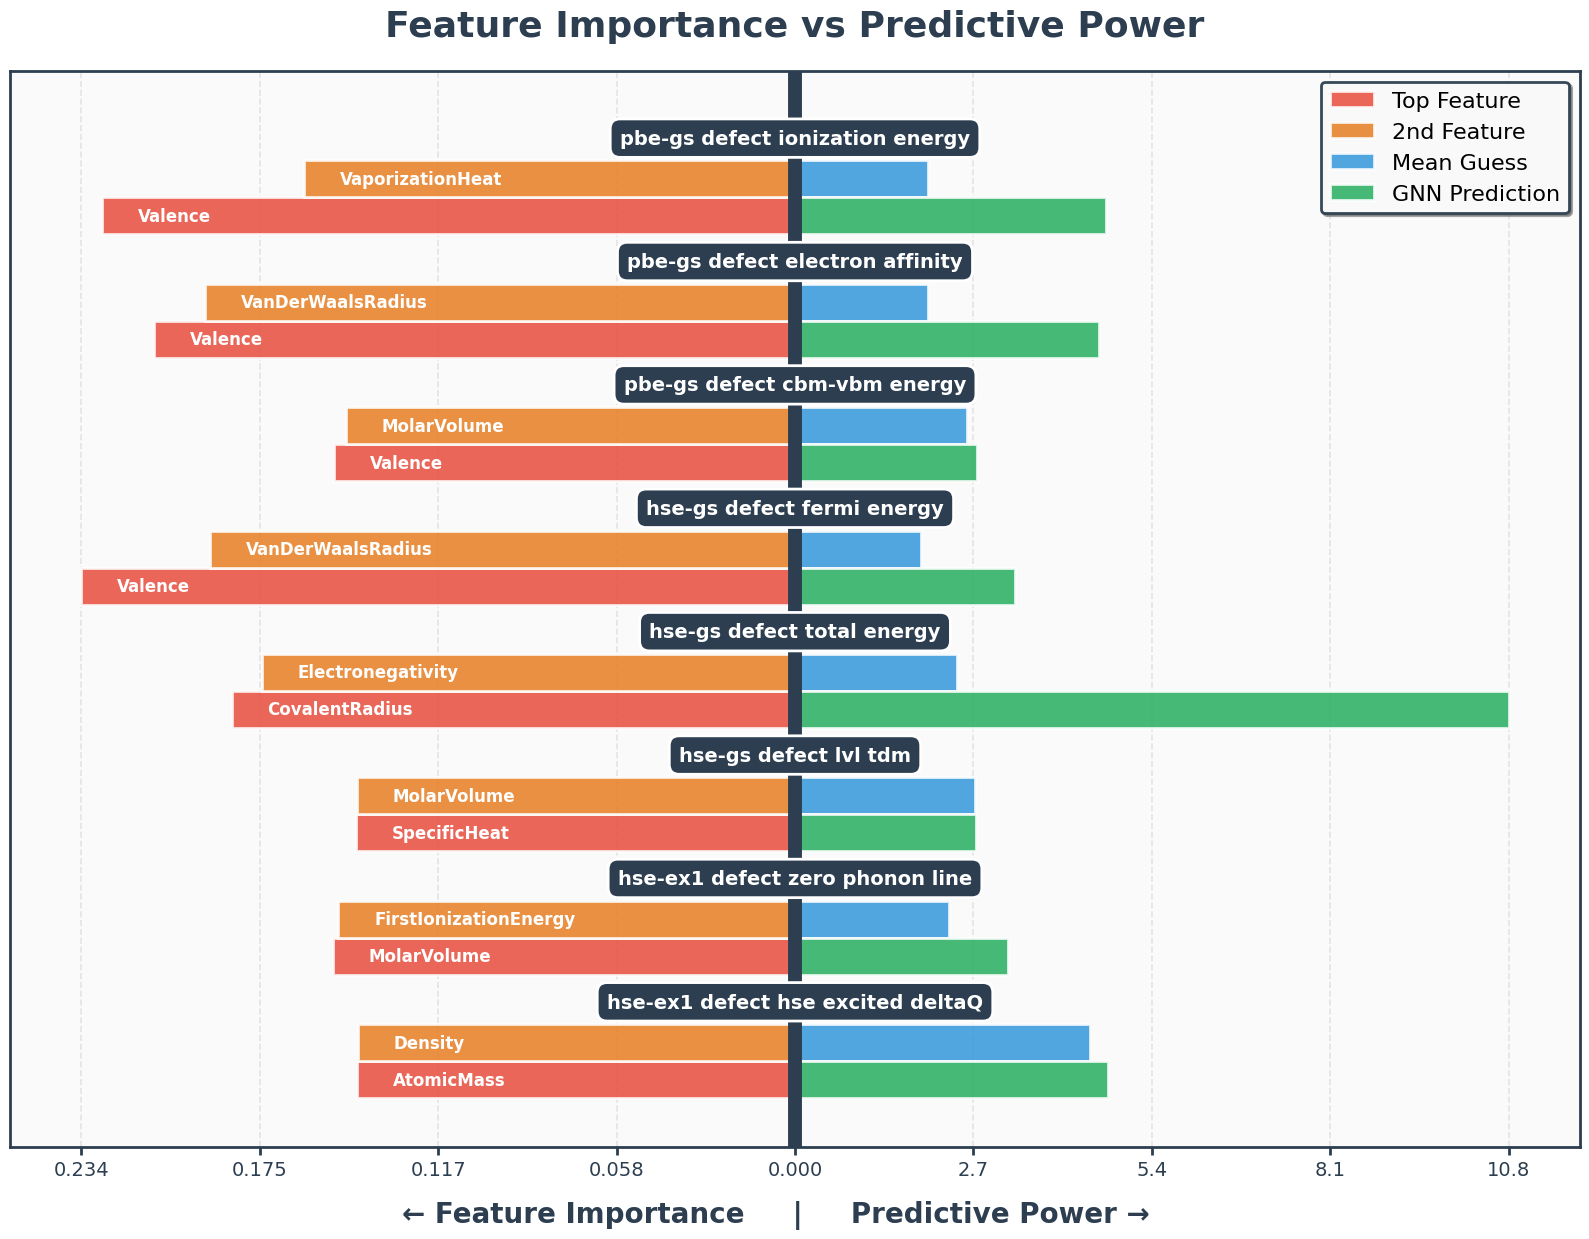

In [108]:
# Example usage: Compare feature importance and predictive power across models
LABELS = [
    ('hse-ex1', 'defect_hse_excited_deltaQ', '4.0'),
    ("hse-ex1", "defect_zero_phonon_line", '4.0'), 
    ('hse-gs', 'defect_lvl_tdm', '4.0'),
    ('hse-gs', 'defect_total_energy', '4.0'), 
    ('hse-gs', 'defect_fermi_energy', '4.0'),
    ('pbe-gs', 'defect_cbm-vbm_energy', '4.0'),
    #('pbe-gs', 'defect_initial_pbe_deltaQ', '4.0'),
    #('pbe-gs', 'defect_initial_pbe_deltaR', '4.0'),
    ('pbe-gs', 'defect_electron_affinity', '4.0'),
    ('pbe-gs', 'defect_ionization_energy', '4.0')
]

results = feature_importance_and_power_plot(LABELS, num_samples=50)